In [ ]:
import tensorflow as tf
# Aumento de datos
from tensorflow.keras.preprocessing.image import ImageDataGenerator
# crea el data set
datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    width_shift_range=0.15,
    height_shift_range=0.15,
    shear_range=0.15,
    zoom_range=0.15,
    horizontal_flip=True,
    brightness_range=[0.8, 1.2],
    validation_split=0.2
)

# generar set para entrenamiento y pruebas
data_gen_entrenamiento = datagen.flow_from_directory('dataset/', target_size=(160, 160),
                                                     batch_size=32,subset='training', shuffle=True,class_mode='categorical')
data_gen_pruebas = datagen.flow_from_directory('dataset/', target_size=(160, 160),
                                               batch_size=32, subset='validation', shuffle=True,class_mode='categorical')

base_model = tf.keras.applications.MobileNetV2(input_shape=(160,160,3), include_top=False, weights='imagenet')
base_model.trainable = False
model = tf.keras.Sequential([
    base_model,
    
    tf.keras.layers.Conv2D(32, (3, 3), activation='relu', padding='same'),
    tf.keras.layers.Flatten(),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Dense(800, 'relu',kernel_regularizer=tf.keras.regularizers.L1L2()),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Dense(512, 'relu',kernel_regularizer=tf.keras.regularizers.L1L2()),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Dense(128, 'relu',kernel_regularizer=tf.keras.regularizers.L1L2()),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Dense(64, 'relu',kernel_regularizer=tf.keras.regularizers.L1L2()),
    
    tf.keras.layers.Dropout(0.5),
    tf.keras.layers.Dense(4, activation='softmax')
])
model.summary()

Found 320 images belonging to 4 classes.
Found 80 images belonging to 4 classes.


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_160            │ (None, 5, 5, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 5, 5, 32)       │       368,672 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_5 (Flatten)             │ (None, 800)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_15          │ (None, 800)            │         3,200 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 800)            │       640,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_16          │ (None, 800)            │         3,200 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_18 (Dense)                │ (None, 512)            │       410,112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_17          │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_19 (Dense)                │ (None, 128)            │        65,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_18          │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_20 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_21 (Dense)                │ (None, 4)              │           260 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,760,708 (14.35 MB)

 Trainable params: 1,498,244 (5.72 MB)

 Non-trainable params: 2,262,464 (8.63 MB)

In [26]:
model.compile(loss='categorical_crossentropy',
              optimizer=tf.keras.optimizers.RMSprop(learning_rate=0.0001),
              metrics=['acc'])
model_fit = model.fit(data_gen_entrenamiento,
                      steps_per_epoch=10,
                      epochs=50,
                      validation_data=data_gen_pruebas,
                      validation_steps=3
)

/home/rodrigo/Documentos/Prog/Python/entV/lib/python3.12/site-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 13s 747ms/step - acc: 0.3180 - loss: 2.0077 - val_acc: 0.3250 - val_loss: 1.4781
Epoch 2/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 5s 539ms/step - acc: 0.3857 - loss: 1.7284 - val_acc: 0.3750 - val_loss: 1.3229
Epoch 3/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 6s 550ms/step - acc: 0.5195 - loss: 1.2523 - val_acc: 0.4000 - val_loss: 1.2208
Epoch 4/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 5s 540ms/step - acc: 0.5467 - loss: 1.2412 - val_acc: 0.4875 - val_loss: 1.1084
Epoch 5/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 6s 548ms/step - acc: 0.5783 - loss: 0.9624 - val_acc: 0.5375 - val_loss: 0.9356
Epoch 6/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 6s 553ms/step - acc: 0.6017 - loss: 0.9421 - val_acc: 0.5125 - val_loss: 0.9197
Epoch 7/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 6s 549ms/step - acc: 0.6152 - loss: 0.8868 - val_acc: 0.5750 - val_loss: 0.8775
Epoch 8/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 6s 550ms/step - acc: 0.6984 - loss: 0.7700 - val_acc: 0.5875 - val_loss: 0.8499
Epoch 9/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 6s 554ms/step - a

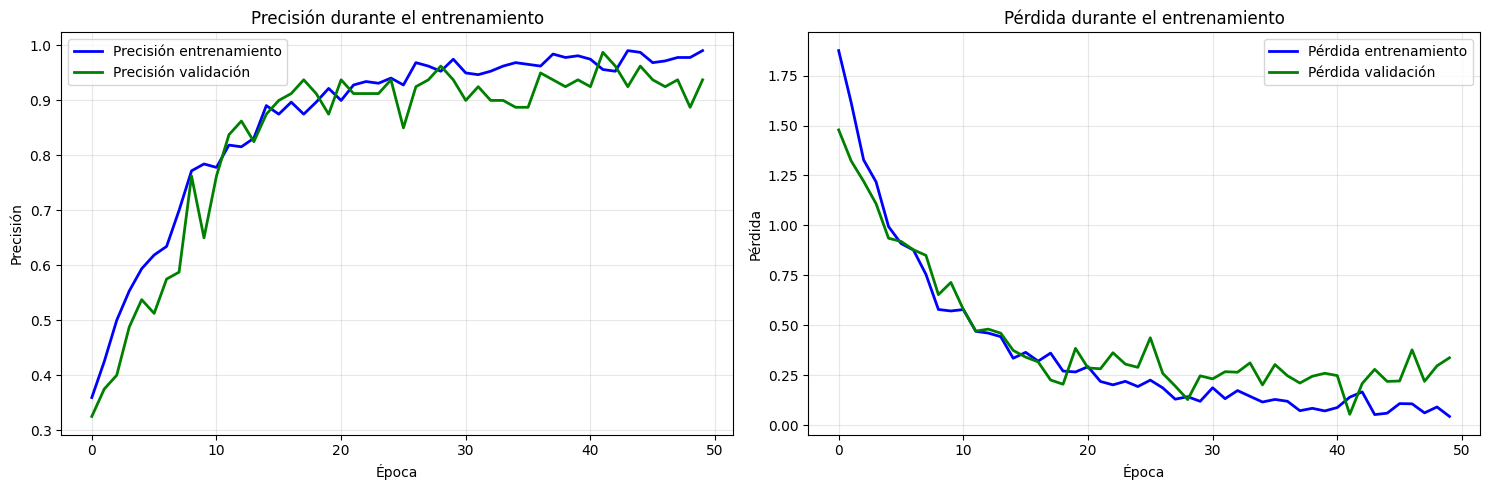

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 418ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 412ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 203ms/step


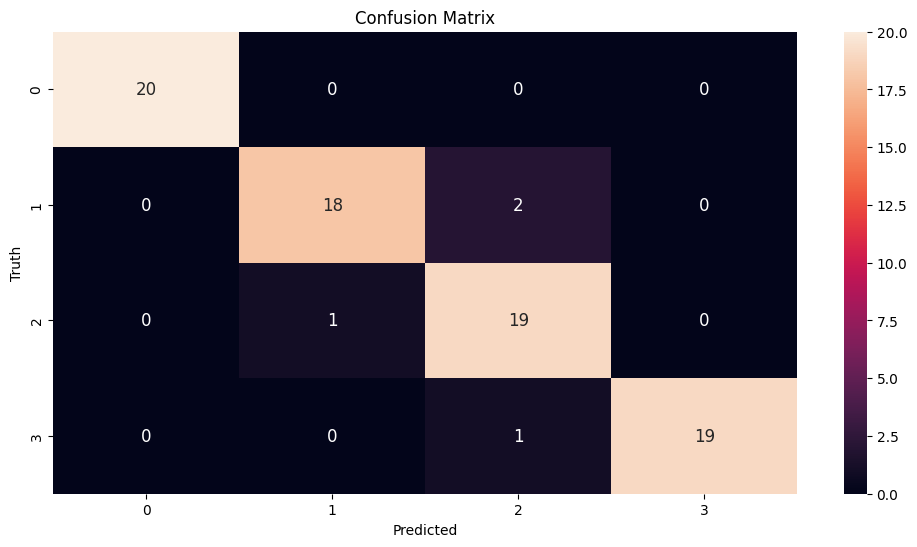

In [28]:
import matplotlib.pyplot as plt
import numpy as np
# Crear figura con subplots horizontales (1 fila, 2 columnas)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

# Subplot 1: Precisión
ax1.plot(model_fit.history['acc'], label='Precisión entrenamiento', color='blue', linewidth=2)
ax1.plot(model_fit.history['val_acc'], label='Precisión validación', color='green', linewidth=2)
ax1.set_xlabel('Época')
ax1.set_ylabel('Precisión')
ax1.legend()
ax1.set_title('Precisión durante el entrenamiento')
ax1.grid(True, alpha=0.3)

# Subplot 2: Pérdida
ax2.plot(model_fit.history['loss'], label='Pérdida entrenamiento', color='blue', linewidth=2)
ax2.plot(model_fit.history['val_loss'], label='Pérdida validación', color='green', linewidth=2)
ax2.set_xlabel('Época')
ax2.set_ylabel('Pérdida')
ax2.legend()
ax2.set_title('Pérdida durante el entrenamiento')
ax2.grid(True, alpha=0.3)

# Ajustar espaciado y mostrar
plt.tight_layout()
plt.show()

# Obtener etiquetas verdaderas y predichas
y_true = []
y_pred = []

for i in range(len(data_gen_pruebas)):
    x_batch, y_batch = data_gen_pruebas[i]
    preds = model.predict(x_batch)
    y_true.extend(np.argmax(y_batch, axis=1))
    y_pred.extend(np.argmax(preds, axis=1))

    # Opcional: detener si ya recorriste todo el set de validación
    if (i+1)*data_gen_pruebas.batch_size >= data_gen_pruebas.samples:
        break

import matplotlib.pyplot as plt
cm = tf.math.confusion_matrix(labels=y_true, predictions=y_pred)
# Plot the confusion matrix as a heatmap.
plt.figure(figsize=[12, 6])
import seaborn as sn

sn.heatmap(cm, annot=True, fmt="d", annot_kws={"size": 12})
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Truth")
plt.show()

In [9]:
from tensorflow.keras.preprocessing import image

# Ruta de la imagen a probar
img_path = 'dataset/isis/rostro_3.jpg'  # Cambia por tu imagen
#img_path = 'dataset/rodrigo/rostro_10.jpg'  # Cambia por tu imagen
#img_path = 'dataset/ignacio/rostro_30.jpg'  # Cambia por tu imagen

# Cargar y preprocesar la imagen
img = image.load_img(img_path, target_size=(160, 160))
img_array = image.img_to_array(img)
img_array = img_array / 255.0  # Normaliza igual que en el entrenamiento
img_array = np.expand_dims(img_array, axis=0)  # Añade dimensión batch
pred = model.predict(img_array)
print(f"Predicción bruta: {pred[0][0]}")

# Umbral para decidir si es "yo" o "no yo"
pred = model.predict(img_array)
clase = np.argmax(pred[0])
print(f"Clase predicha: {clase}, probabilidades: {pred[0]}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
Predicción bruta: 0.002913043135777116
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
Clase predicha: 1, probabilidades: [2.9130431e-03 9.9055755e-01 8.3177605e-05 6.4463504e-03]


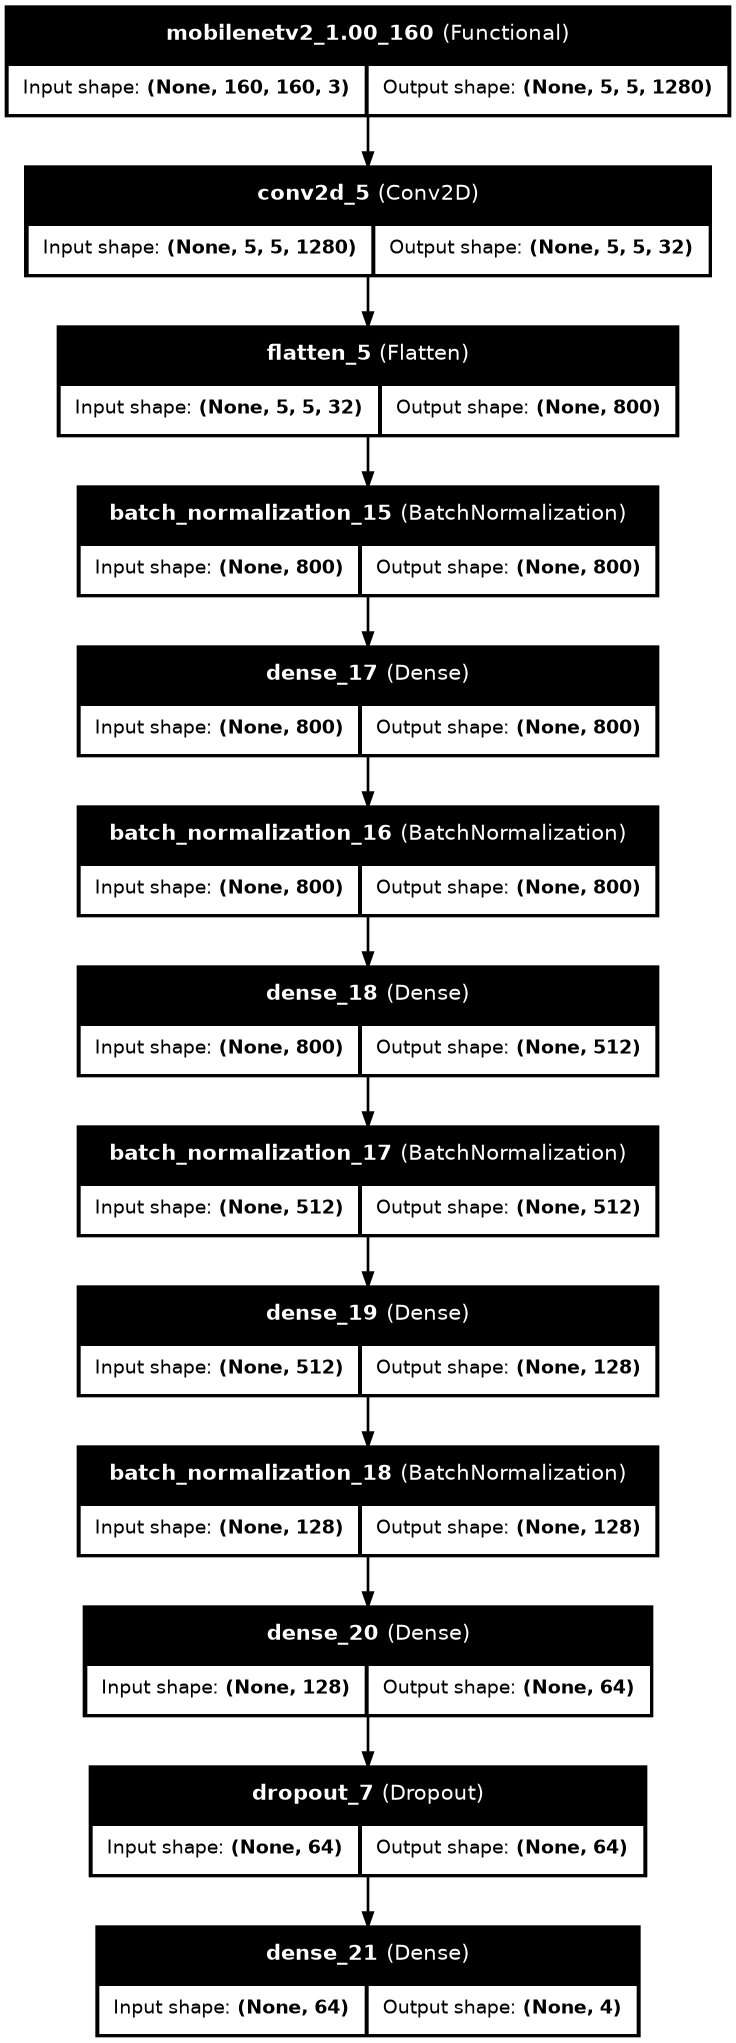

In [31]:
from tensorflow.keras.utils import plot_model
plot_model(
    model,
    to_file='model_architecture.png',
    show_shapes=True,
    show_layer_names=True,
    rankdir='TB',  # 'TB' para vertical, 'LR' para horizontal
    dpi=96,
    layer_range=None,  # Opcional: filtrar capas (ej. ['input_1', 'conv2d_1'])
)

In [ ]:
#guarda modelo
model.export('complementos/modelos/modelo_exportado')
# Convierte directamente desde la carpeta SavedModel
converter = tf.lite.TFLiteConverter.from_saved_model('complementos/modelos/modelo_exportado')
tflite_model = converter.convert()

# Guarda el modelo TFLite
with open('complementos/modelos/modelo_exportado/modelo_exp1.tflite', 'wb') as f:
    f.write(tflite_model)

INFO:tensorflow:Assets written to: modelo_exportado/assets


INFO:tensorflow:Assets written to: modelo_exportado/assets


Saved artifact at 'modelo_exportado'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 160, 160, 3), dtype=tf.float32, name='keras_tensor_798')
Output Type:
  TensorSpec(shape=(None, 4), dtype=tf.float32, name=None)
Captures:
  137535895541840: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137535895540688: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137535895541072: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137535895539728: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137535895542800: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137535895541264: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137535895538000: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137535895537424: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137535895545296: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137535895539536: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1375358955

W0000 00:00:1758484995.466192   11078 tf_tfl_flatbuffer_helpers.cc:365] Ignored output_format.
W0000 00:00:1758484995.466213   11078 tf_tfl_flatbuffer_helpers.cc:368] Ignored drop_control_dependency.
2025-09-21 14:03:15.466510: I tensorflow/cc/saved_model/reader.cc:83] Reading SavedModel from: modelo_exportado
2025-09-21 14:03:15.482091: I tensorflow/cc/saved_model/reader.cc:52] Reading meta graph with tags { serve }
2025-09-21 14:03:15.482124: I tensorflow/cc/saved_model/reader.cc:147] Reading SavedModel debug info (if present) from: modelo_exportado
2025-09-21 14:03:15.647983: I tensorflow/cc/saved_model/loader.cc:236] Restoring SavedModel bundle.
2025-09-21 14:03:16.604745: I tensorflow/cc/saved_model/loader.cc:220] Running initialization op on SavedModel bundle at path: modelo_exportado
2025-09-21 14:03:16.844380: I tensorflow/cc/saved_model/loader.cc:471] SavedModel load for tags { serve }; Status: success: OK. Took 1377875 microseconds.
